# Homework assignment №7
## Author: Danuta Grabovska

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
np.random.seed(42)

Binary cross-entropy loss:

$$
L(y, z) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z))
$$

where $y_i \in \{0,1\}$ and $\sigma(z) = \frac{1}{1 + e^{-z}}$

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y, z):
    sigma_z = sigmoid(z)
    eps = 1e-15
    sigma_z = np.clip(sigma_z, eps, 1 - eps)
    return -y * np.log(sigma_z) - (1 - y) * np.log(1 - sigma_z)

Dataset setup: m ones, k zeros, total n samples. Random predictions f_prev from previous stage.

In [4]:
m = 60
k = 40
n = m + k

y = np.array([1] * m + [0] * k)
f_prev = np.random.randn(n) * 2

print(f"n = {n}, m = {m}, k = {k}")
print(f"f_prev sample: {f_prev[:5]}")

n = 100, m = 60, k = 40
f_prev sample: [ 0.99342831 -0.2765286   1.29537708  3.04605971 -0.46830675]


## Scenario A: From Scratch

Finding optimal constant $\lambda$ that minimizes:
$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda)
$$

### Derivation

Take derivative of loss wrt λ. First need derivative of sigmoid:

$$\frac{d\sigma}{d\lambda} = \sigma(\lambda)(1 - \sigma(\lambda))$$

Then for binary cross entropy:

$$\frac{\partial L}{\partial \lambda} = \sigma(\lambda) - y$$

Setting sum of derivatives to zero:

$$\sum_{i=1}^{n} (\sigma(\lambda) - y_i) = 0$$

Since \sigma(λ) is same for all i:

$$n \cdot \sigma(\lambda^*) = m$$

$$\sigma(\lambda^*) = \frac{m}{n}$$

Inverting sigmoid:

$$\lambda^* = \log\left(\frac{m}{k}\right)$$

So for our data: $\lambda^* = \log(60/40) = \log(1.5) \approx 0.405$

This makes sense - optimal prediction is just the proportion of positive labels (60%).

In [5]:
def loss_scenario_a(lam, y):
    return np.sum(binary_cross_entropy(y, lam))

lambda_star_a = np.log(m / k)

print(f"Optimal λ* = {lambda_star_a:.4f}")
print(f"σ(λ*) = {sigmoid(lambda_star_a):.4f} = {m/n:.4f}")

Optimal λ* = 0.4055
σ(λ*) = 0.6000 = 0.6000


## Scenario B: Forward Stagewise

Now we have existing predictions $f_i$ and want to add constant $\lambda$:

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, f_i + \lambda)
$$

### Derivation

Using chain rule:

$$\frac{\partial L(y_i, f_i + \lambda)}{\partial \lambda} = \sigma(f_i + \lambda) - y_i$$

Sum over all points and set to zero:

$$\sum_{i=1}^{n} \sigma(f_i + \lambda^*) = m$$

**Problem:** Each $\sigma(f_i + λ)$ is different because $f_i$ varies! Can't factor it out like before.

This equation has no closed-form solution. The sum of 100 different sigmoid functions with different $f_i$ values can't be simplified algebraically.

We need to solve it numerically.

In [6]:
def loss_scenario_b(lam, y, f_prev):
    return np.sum(binary_cross_entropy(y, f_prev + lam))

result_b = minimize_scalar(lambda lam: loss_scenario_b(lam, y, f_prev), method='brent')
lambda_star_b = result_b.x

print(f"Optimal λ* (numerical) = {lambda_star_b:.4f}")
print(f"Loss = {result_b.fun:.4f}")

Optimal λ* (numerical) = 0.8088
Loss = 104.3087


## Plots

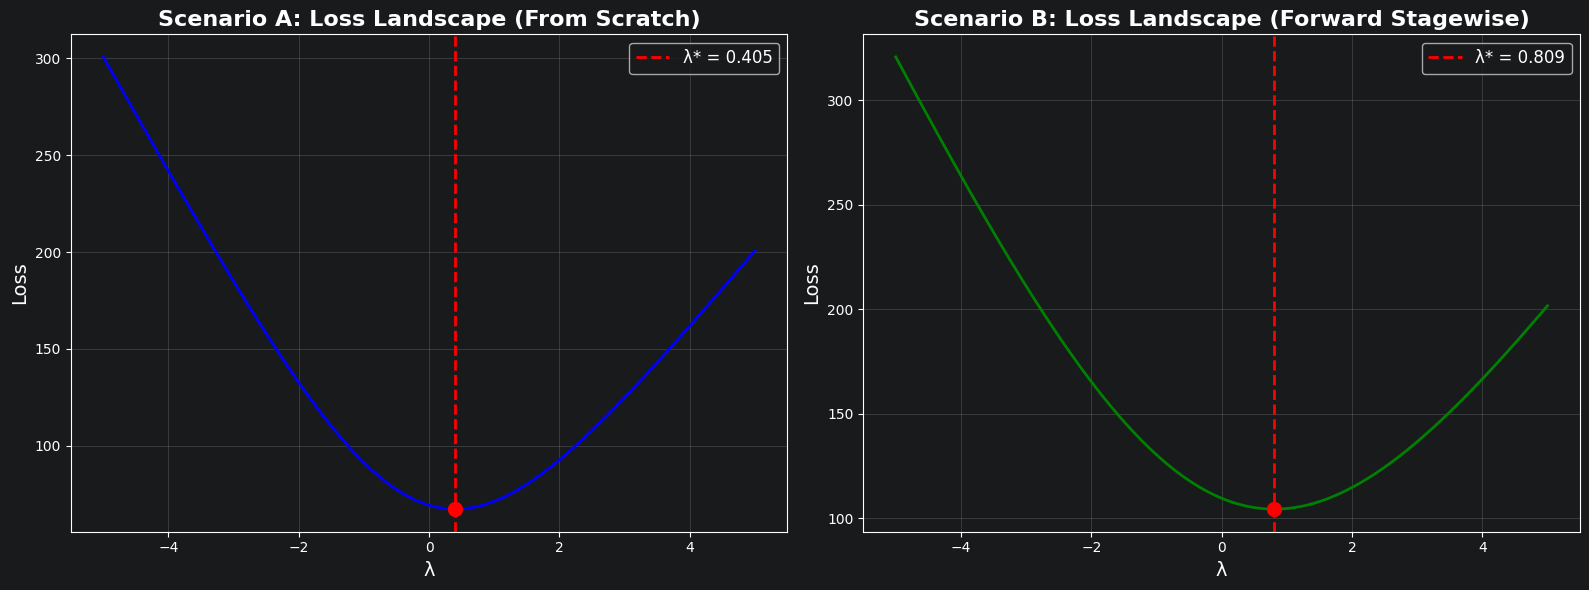

In [7]:
lambda_range = np.linspace(-5, 5, 500)
losses_a = [loss_scenario_a(lam, y) for lam in lambda_range]
losses_b = [loss_scenario_b(lam, y, f_prev) for lam in lambda_range]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(lambda_range, losses_a, 'b-', linewidth=2)
axes[0].axvline(lambda_star_a, color='r', linestyle='--', linewidth=2, 
                label=f'λ* = {lambda_star_a:.3f}')
axes[0].scatter([lambda_star_a], [loss_scenario_a(lambda_star_a, y)], 
                color='r', s=100, zorder=5)
axes[0].set_xlabel('λ', fontsize=14)
axes[0].set_ylabel('Loss', fontsize=14)
axes[0].set_title('Scenario A: Loss Landscape (From Scratch)', fontsize=16, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(lambda_range, losses_b, 'g-', linewidth=2)
axes[1].axvline(lambda_star_b, color='r', linestyle='--', linewidth=2,
                label=f'λ* = {lambda_star_b:.3f}')
axes[1].scatter([lambda_star_b], [loss_scenario_b(lambda_star_b, y, f_prev)],
                color='r', s=100, zorder=5)
axes[1].set_xlabel('λ', fontsize=14)
axes[1].set_ylabel('Loss', fontsize=14)
axes[1].set_title('Scenario B: Loss Landscape (Forward Stagewise)', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

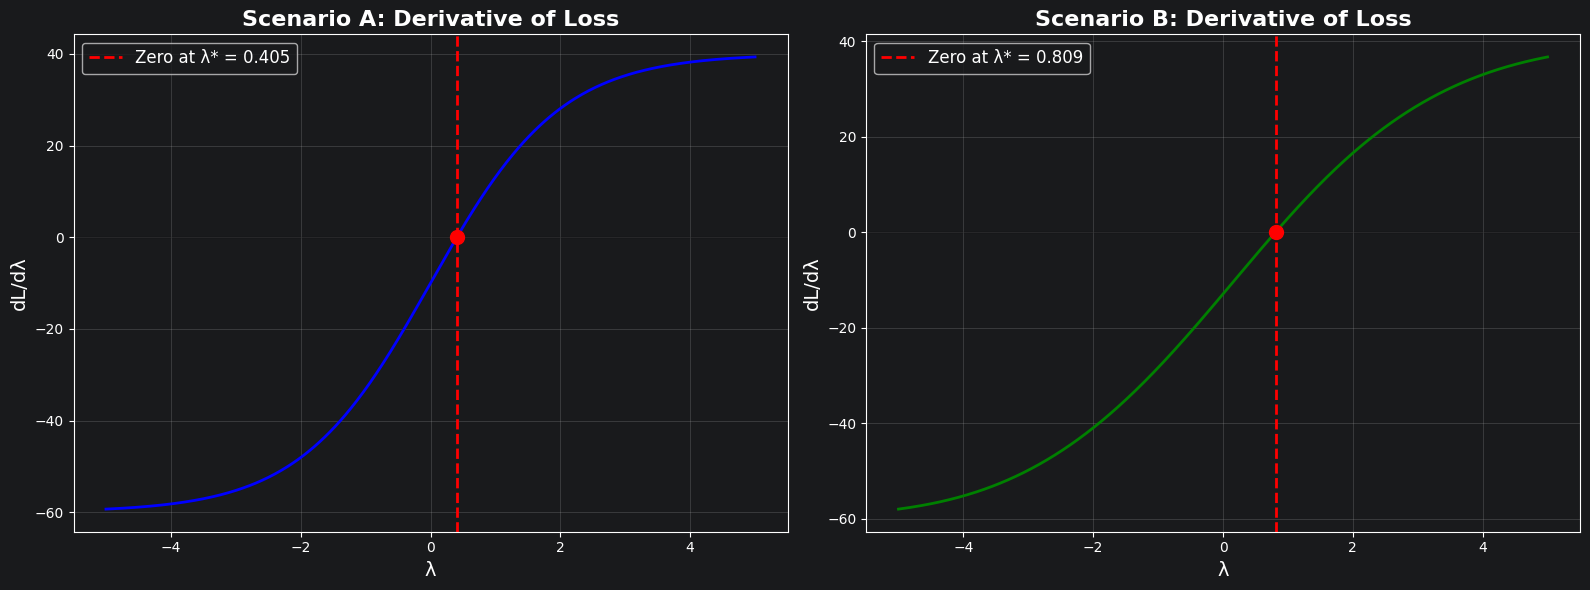

In [8]:
def derivative_scenario_a(lam, y):
    return np.sum(sigmoid(lam) - y)

def derivative_scenario_b(lam, y, f_prev):
    return np.sum(sigmoid(f_prev + lam) - y)

derivatives_a = [derivative_scenario_a(lam, y) for lam in lambda_range]
derivatives_b = [derivative_scenario_b(lam, y, f_prev) for lam in lambda_range]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(lambda_range, derivatives_a, 'b-', linewidth=2)
axes[0].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[0].axvline(lambda_star_a, color='r', linestyle='--', linewidth=2,
                label=f'Zero at λ* = {lambda_star_a:.3f}')
axes[0].scatter([lambda_star_a], [0], color='r', s=100, zorder=5)
axes[0].set_xlabel('λ', fontsize=14)
axes[0].set_ylabel('dL/dλ', fontsize=14)
axes[0].set_title('Scenario A: Derivative of Loss', fontsize=16, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(lambda_range, derivatives_b, 'g-', linewidth=2)
axes[1].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[1].axvline(lambda_star_b, color='r', linestyle='--', linewidth=2,
                label=f'Zero at λ* = {lambda_star_b:.3f}')
axes[1].scatter([lambda_star_b], [0], color='r', s=100, zorder=5)
axes[1].set_xlabel('λ', fontsize=14)
axes[1].set_ylabel('dL/dλ', fontsize=14)
axes[1].set_title('Scenario B: Derivative of Loss', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

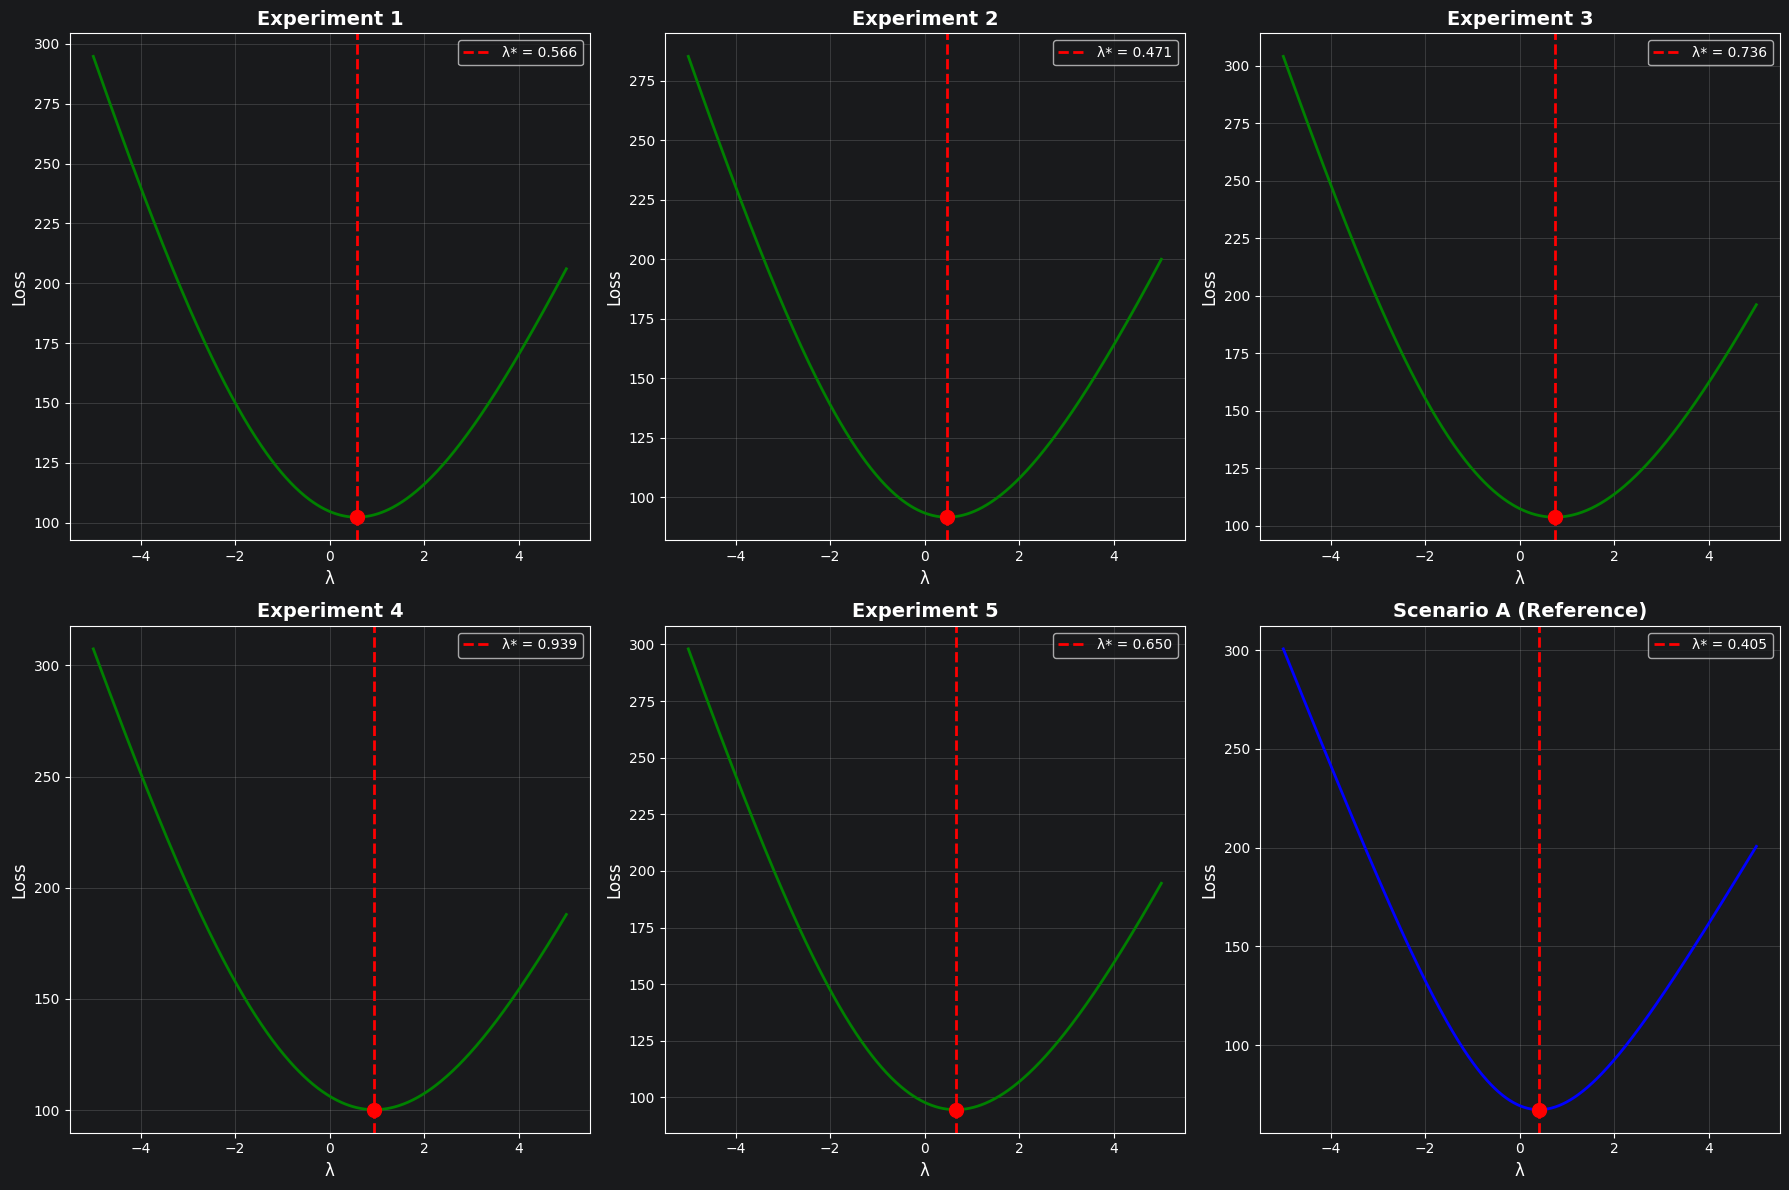

In [9]:
n_experiments = 5
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for exp in range(n_experiments):
    np.random.seed(exp * 10)
    f_prev_exp = np.random.randn(n) * 2
    
    losses_b_exp = [loss_scenario_b(lam, y, f_prev_exp) for lam in lambda_range]
    result_b_exp = minimize_scalar(lambda lam: loss_scenario_b(lam, y, f_prev_exp), method='brent')
    lambda_star_b_exp = result_b_exp.x
    
    axes[exp].plot(lambda_range, losses_b_exp, 'g-', linewidth=2)
    axes[exp].axvline(lambda_star_b_exp, color='r', linestyle='--', linewidth=2,
                     label=f'λ* = {lambda_star_b_exp:.3f}')
    axes[exp].scatter([lambda_star_b_exp], [loss_scenario_b(lambda_star_b_exp, y, f_prev_exp)],
                     color='r', s=100, zorder=5)
    axes[exp].set_xlabel('λ', fontsize=12)
    axes[exp].set_ylabel('Loss', fontsize=12)
    axes[exp].set_title(f'Experiment {exp+1}', fontsize=14, fontweight='bold')
    axes[exp].legend(fontsize=10)
    axes[exp].grid(True, alpha=0.3)

# Reference plot
axes[5].plot(lambda_range, losses_a, 'b-', linewidth=2)
axes[5].axvline(lambda_star_a, color='r', linestyle='--', linewidth=2,
               label=f'λ* = {lambda_star_a:.3f}')
axes[5].scatter([lambda_star_a], [loss_scenario_a(lambda_star_a, y)],
               color='r', s=100, zorder=5)
axes[5].set_xlabel('λ', fontsize=12)
axes[5].set_ylabel('Loss', fontsize=12)
axes[5].set_title('Scenario A (Reference)', fontsize=14, fontweight='bold')
axes[5].legend(fontsize=10)
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis

### Loss Landscapes

Both scenarios produce smooth, unimodal curves. Scenario A is a perfect parabola with minimum at $\lambda^*$ = 0.405. Scenario B also looks smooth across all 5 random initializations - the optimal $\lambda^*$  moves around (0.47 to 0.94) depending on the random $f_i$ values, but the shape stays similar.

I expected Scenario B to be messier but it's not. Both are unimodal with no weird bumps or multiple minima.

### Why is B harder?

The difficulty isn't from a complex landscape - both plots look fine. The problem is purely mathematical.

In A: We get $n·\sigma(\lambda) = m$ which solves to $\lambda = log(m/k)$. Simple algebra.

In B: We get $\sum \sigma(f_i + \lambda) = m$ where each $f_i$ is different. Can't simplify this - it's an implicit equation with no closed-form solution.

But even though we're summing 100 non-linear functions, the result is smooth because sigmoid is smooth and averaging many of them smooths it out more.

### Numerical optimization

Can we solve B numerically? Yes easily. The smooth unimodal landscape means scipy.optimize converges instantly. No practical difficulty, just theoretical - we need a computer instead of a formula.

### Conclusion

Scenario B is harder because of non-linearity in the implicit equation, not because of a messy loss landscape. Both have smooth convex functions that are easy to optimize numerically.

This explains why gradient boosting works - at each stage we face Scenario B type problems with no exact solutions, but the landscapes are smooth so gradient descent works fine. Don't need analytical solutions when numerical optimization is this easy.